<a href="https://colab.research.google.com/github/IVMRanepa/courses.shift01/blob/main/ds_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Модуль 1 · пример кодовой ячейки**

In [ ]:
# Постановка аналитической задачи
business_goal = "Снизить отток клиентов"
target = "churn"
metric = "roc_auc"
constraints = ["ограничение по времени", "неполные данные", "интерпретируемость"]

print({
    "business_goal": business_goal,
    "target": target,
    "metric": metric,
    "constraints": constraints
})

{'business_goal': 'Снизить отток клиентов', 'target': 'churn', 'metric': 'roc_auc', 'constraints': ['ограничение по времени', 'неполные данные', 'интерпретируемость']}


Стартовая структура такого рода помогает преподавателю показать, что Data Science начинается не с модели, а с корректной формализации задачи и критериев качества.

# **Модуль 2 · пример гипотезы**

In [ ]:
import scipy.stats as st
control = [102, 98, 97, 105, 100, 103]
test = [110, 111, 108, 109, 112, 107]
stat, p = st.ttest_ind(control, test, equal_var=False)
print(f"t-stat={stat:.3f}, p-value={p:.5f}")

if p < 0.05:
    print("Есть статистически значимое различие")
else:
    print("Недостаточно оснований отвергнуть H0")

t-stat=-5.918, p-value=0.00031
Есть статистически значимое различие


Этот фрагмент удобно использовать как преподавательский минимальный шаблон для обсуждения эксперимента, нулевой гипотезы и принятия решений.

# **Модуль 3 · минимальный pipeline**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Пример конвейера
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

# **Модуль 4 · очистка данных**

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "age": [25, None, 31, 31, 120],
    "income": [50000, 52000, None, 52000, 49000]
})

df = df.drop_duplicates()
df["age"] = df["age"].clip(upper=90)
df["age"] = df["age"].fillna(df["age"].median())
df["income"] = df["income"].fillna(df["income"].median())
print(df)

    age   income
0  25.0  50000.0
1  31.0  52000.0
2  31.0  51000.0
3  31.0  52000.0
4  90.0  49000.0


# **Модуль 5 · feature engineering**

In [ ]:
# Импортируем библиотеку pandas для работы с табличными данными
import pandas as pd

# Создаем DataFrame с данными о недвижимости
df = pd.DataFrame({
    "price": [100, 120, 90], # Цены объектов
    "area": [40, 50, 30],   # Площадь объектов в м2
    "rooms": [1, 2, 1]      # Количество комнат
})

# Добавляем новый признак: цена за квадратный метр
df["price_per_m2"] = df["price"] / df["area"]
# Добавляем новый признак: является ли квартира маленькой (площадь менее 35 м2), преобразуем булево значение в целое число (0 или 1)
df["is_small_flat"] = (df["area"] < 35).astype(int)
# Выводим обновленный DataFrame
print(df)

   price  area  rooms  price_per_m2  is_small_flat
0    100    40      1           2.5              0
1    120    50      2           2.4              0
2     90    30      1           3.0              1


# **Модуль 6 · расчёт метрик**

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

y_true = [1,0,1,1,0,1]
y_pred = [1,0,1,0,0,1]

print("accuracy =", accuracy_score(y_true, y_pred))
print("f1 =", f1_score(y_true, y_pred))

accuracy = 0.8333333333333334
f1 = 0.8571428571428571


# **Модуль 7 · пример визуализации**

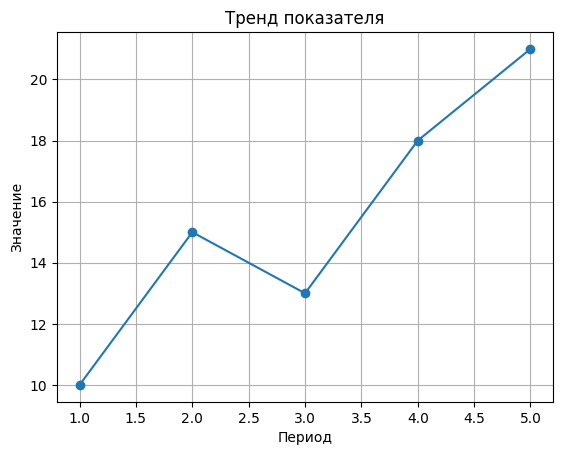

In [ ]:
import matplotlib.pyplot as plt

x = [1,2,3,4,5]
y = [10,15,13,18,21]

plt.plot(x, y, marker='o')
plt.title('Тренд показателя')
plt.xlabel('Период')
plt.ylabel('Значение')
plt.grid(True)
plt.show()

# **Модуль 8 · SQL и Python**

In [ ]:
# Устанавливаем библиотеку pandasql, если она еще не установлена
!pip install -q pandasql

# Импортируем функцию sqldf из pandasql
from pandasql import sqldf
import pandas as pd

# Создаем пример DataFrame 'flats', который будет использоваться в SQL-запросе
flats = pd.DataFrame({
    'city': ['Москва', 'Санкт-Петербург', 'Москва', 'Екатеринбург', 'Санкт-Петербург'],
    'price': [150, 120, 160, 80, 130]
})

# Выполняем SQL-запрос с помощью sqldf
result = sqldf("""
SELECT city, AVG(price) AS avg_price
FROM flats
GROUP BY city
ORDER BY avg_price DESC;
""", globals())

# Выводим результат
print(result)

  Preparing metadata (setup.py) ... done
              city  avg_price
0           Москва      155.0
1  Санкт-Петербург      125.0
2     Екатеринбург       80.0


In [ ]:
# Python
import pandas as pd
query_result = pd.DataFrame({
    'city':['Moscow','SPb'],
    'avg_price':[12.5, 9.3]
})
print(query_result)

     city  avg_price
0  Moscow       12.5
1     SPb        9.3
